# DURCL Course Project Notebook

This notebook is the single-file deliverable for the Adaptive Environment Selection course project.
It is organized into three parts:

1. **Training pipeline**: dataset access, project-specific training code, scheduler implementation, and the exact heavy-training command path.
2. **Evaluation pipeline**: checked-in result aggregation by default, with an optional checkpoint-based evaluation entrypoint.
3. **Result interpretation**: tables, figures, toy sanity checks, and the written analysis used in the report.

The notebook is designed to be **self-bootstrapping**:

- If it is run inside a cloned copy of the repository, it uses the local files directly.
- If it is run as a standalone notebook, it can download the repository snapshot from GitHub.
- Large artifacts such as model checkpoints are intentionally loaded by link rather than embedded in the notebook.

Heavy RL training is **not executed by default** because it requires a compatible multi-GPU environment, but the code path and command construction are included here so the full workflow is documented in one place.


In [1]:
from __future__ import annotations

import importlib
import json
import math
import os
import shutil
import subprocess
import sys
import textwrap
import urllib.request
import zipfile
from pathlib import Path


def ensure_packages(packages: list[str]) -> None:
    missing = []
    for pkg in packages:
        module = pkg.split("==", 1)[0].split(">=", 1)[0]
        module = {"pillow": "PIL", "pyarrow": "pyarrow"}.get(module, module)
        try:
            importlib.import_module(module)
        except Exception:
            missing.append(pkg)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])


ensure_packages([
    "pandas",
    "matplotlib",
    "pillow",
    "pyarrow",
    "reportlab",
    "pytest",
])

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Code, Image, Markdown, display


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)


In [2]:
RUN_UNIT_TESTS = True
RUN_HEAVY_TRAINING = False
RUN_CHECKPOINT_EVAL = False
REGENERATE_FIGURES = False
RERUN_TOY_SIMULATION = False

REPO_URL = "https://github.com/kkkzzz0101/Adaptive-Env-Selection.git"
REPO_ZIP_URL = "https://github.com/kkkzzz0101/Adaptive-Env-Selection/archive/refs/heads/main.zip"
RAW_BASE = "https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main"

HF_MODEL_ID = os.environ.get("AES_HF_MODEL_ID", "").strip()
CHECKPOINT_ARCHIVE_URL = os.environ.get("AES_CHECKPOINT_ARCHIVE_URL", "").strip()
LOCAL_MODEL_PATH = os.environ.get("AES_LOCAL_MODEL_PATH", "").strip()
HF_TOKEN = (
    os.environ.get("HF_TOKEN", "").strip()
    or os.environ.get("HUGGINGFACE_HUB_TOKEN", "").strip()
)

print({
    "RUN_UNIT_TESTS": RUN_UNIT_TESTS,
    "RUN_HEAVY_TRAINING": RUN_HEAVY_TRAINING,
    "RUN_CHECKPOINT_EVAL": RUN_CHECKPOINT_EVAL,
    "REGENERATE_FIGURES": REGENERATE_FIGURES,
    "RERUN_TOY_SIMULATION": RERUN_TOY_SIMULATION,
})


{'RUN_UNIT_TESTS': True, 'RUN_HEAVY_TRAINING': False, 'RUN_CHECKPOINT_EVAL': False, 'REGENERATE_FIGURES': False, 'RERUN_TOY_SIMULATION': False}


In [3]:
NOTEBOOK_CWD = Path.cwd()


def github_raw_url(path: str) -> str:
    return f"{RAW_BASE}/{path}"


def find_repo_root(start: Path) -> Path | None:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "paper" / "deliverables").exists():
            return candidate
    return None


def download_repo_snapshot(dest_dir: Path) -> Path:
    dest_dir.mkdir(parents=True, exist_ok=True)
    zip_path = dest_dir / "Adaptive-Env-Selection-main.zip"
    extract_dir = dest_dir / "Adaptive-Env-Selection-main"
    if not extract_dir.exists():
        print(f"Downloading repository snapshot from {REPO_ZIP_URL}")
        urllib.request.urlretrieve(REPO_ZIP_URL, zip_path)
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(dest_dir)
    return extract_dir


ROOT = find_repo_root(NOTEBOOK_CWD)
if ROOT is None:
    ROOT = download_repo_snapshot(NOTEBOOK_CWD / "aes_notebook_runtime")
    print(f"Using downloaded repository at: {ROOT}")
else:
    print(f"Using local repository at: {ROOT}")

sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT / "scripts"))


Using local repository at: /Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo


In [4]:
asset_rows = [
    {"artifact": "Repository root", "path": str(ROOT), "exists": ROOT.exists()},
    {"artifact": "Notebook", "path": str(ROOT / "paper/deliverables/project_groupID.ipynb"), "exists": (ROOT / "paper/deliverables/project_groupID.ipynb").exists()},
    {"artifact": "Training data", "path": str(ROOT / "references/sec/data"), "exists": (ROOT / "references/sec/data").exists()},
    {"artifact": "Scheduler source", "path": str(ROOT / "src/scheduler/adaptive_curriculum_scheduler.py"), "exists": (ROOT / "src/scheduler/adaptive_curriculum_scheduler.py").exists()},
    {"artifact": "Eval probe", "path": str(ROOT / "scripts/sec_inference_probe.py"), "exists": (ROOT / "scripts/sec_inference_probe.py").exists()},
    {"artifact": "Result report", "path": str(ROOT / "docs/result_report.md"), "exists": (ROOT / "docs/result_report.md").exists()},
    {"artifact": "Paper figures", "path": str(ROOT / "paper/figures"), "exists": (ROOT / "paper/figures").exists()},
]
display(pd.DataFrame(asset_rows))


,artifact,path,exists
0,Repository root,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo,True
1,Notebook,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/paper/deliverab...,True
2,Training data,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/references/sec/...,True
3,Scheduler source,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/src/scheduler/a...,True
4,Eval probe,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/scripts/sec_inf...,True
5,Result report,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/docs/result_rep...,True
6,Paper figures,/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/paper/figures,True


## Part I. Training Pipeline

The heavy RL runs in this project use the DUMP/verl path together with the project scheduler and SEC-format datasets.
This section keeps all the project-specific training ingredients in one notebook:

- the checked-in datasets,
- the project scheduler implementation,
- the data-preparation and training-entry scripts,
- and a portable reconstruction of the heavy training command.

The notebook documents the full training path, but does **not** launch RL training unless `RUN_HEAVY_TRAINING=True`.


In [5]:
data_root = ROOT / "references" / "sec" / "data"
data_files = sorted(data_root.rglob("*.parquet"))

import pyarrow.parquet as pq

data_rows = []
for path in data_files:
    rel = path.relative_to(ROOT).as_posix()
    data_rows.append({
        "file": rel,
        "rows": pq.read_metadata(path).num_rows,
        "download_url": github_raw_url(rel),
    })

data_df = pd.DataFrame(data_rows).sort_values("file").reset_index(drop=True)
display(data_df)
print(f"Total parquet files: {len(data_df)}")


,file,rows,download_url
0,references/sec/data/arc/test.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/arc/test.parquet
1,references/sec/data/arc/train.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/arc/train.parquet
2,references/sec/data/combined/test_arc.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_arc.parquet
3,references/sec/data/combined/test_countdown.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_countdown...
4,references/sec/data/combined/test_zebra.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/test_zebra.par...
5,references/sec/data/combined/train_arc.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_arc.parquet
6,references/sec/data/combined/train_countdown.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_countdow...
7,references/sec/data/combined/train_zebra.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/combined/train_zebra.pa...
8,references/sec/data/countdown/test.parquet,800,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/countdown/test.parquet
9,references/sec/data/countdown/train.parquet,30000,https://raw.githubusercontent.com/kkkzzz0101/Adaptive-Env-Selection/main/references/sec/data/countdown/train.parquet


Total parquet files: 14


In [6]:
def show_source(rel_path: str, start: int = 1, end: int | None = None) -> None:
    path = ROOT / rel_path
    lines = path.read_text(encoding="utf-8").splitlines()
    if end is None:
        end = len(lines)
    snippet = "\n".join(f"{idx:4d}: {line}" for idx, line in enumerate(lines[start - 1:end], start))
    print(f"--- {rel_path} ---")
    print(snippet)


show_source("scripts/prepare_sec4_random_dataset.py", 1, 140)


--- scripts/prepare_sec4_random_dataset.py ---
   1: #!/usr/bin/env python3
   2: from __future__ import annotations
   3: 
   4: import argparse
   5: import ast
   6: import json
   7: import re
   8: from pathlib import Path
   9: from typing import Any, Tuple
  10: 
  11: import numpy as np
  12: import pandas as pd
  13: 
  14: from prompt_protocol import append_protocol_text, extract_countdown_target, infer_dataset_from_data_source
  15: 
  16: REQUIRED_COLUMNS = ["data_source", "prompt", "ability", "reward_model", "extra_info"]
  17: 
  18: 
  19: def _coerce_prompt_messages(prompt: Any) -> list[dict[str, Any]] | None:
  20:     if isinstance(prompt, list):
  21:         return prompt
  22: 
  23:     if hasattr(prompt, "tolist") and not isinstance(prompt, (str, bytes)):
  24:         try:
  25:             obj = prompt.tolist()
  26:             if isinstance(obj, list):
  27:                 return obj
  28:         except Exception:
  29:             pass
  30: 
  31:     if 

In [7]:
show_source("src/scheduler/adaptive_curriculum_scheduler.py", 1, 220)


--- src/scheduler/adaptive_curriculum_scheduler.py ---
   1: from __future__ import annotations
   2: 
   3: from dataclasses import dataclass, field
   4: from typing import Any, Dict, Iterable, List, Mapping, MutableMapping, Optional, Sequence, Tuple
   5: import math
   6: import random
   7: 
   8: 
   9: @dataclass
  10: class SchedulerConfig:
  11:     num_clusters: int = 3
  12:     decay: float = 0.95
  13:     ucb_beta: float = 1.0
  14:     softmax_tau: float = 0.2
  15:     prob_floor_eps: float = 0.05
  16:     warmup_steps: int = 200
  17:     rebucket_interval: int = 50
  18:     active_window: int = 200
  19:     min_obs_for_rebucket: int = 10
  20:     migration_gamma: float = 2.0
  21:     migration_consecutive: int = 3
  22:     allow_only_neighbor_migration: bool = True
  23:     allow_reverse_migration: bool = False
  24:     seed: int = 42
  25: 
  26:     def __post_init__(self) -> None:
  27:         if self.num_clusters < 2:
  28:             raise ValueError("n

In [8]:
show_source("scripts/run_baseline_random_dump_2gpu.sh", 1, 120)


--- scripts/run_baseline_random_dump_2gpu.sh ---
   1: #!/usr/bin/env bash
   2: set -euo pipefail
   3: 
   4: cd '/root/adaptive env selection'
   5: source /home/vipuser/miniconda3/bin/activate aes
   6: 
   7: export CUDA_VISIBLE_DEVICES=${CUDA_VISIBLE_DEVICES:-0,1}
   8: export PYTHONPATH='/root/adaptive env selection/references/DUMP:'"${PYTHONPATH:-}"
   9: export PYTORCH_CUDA_ALLOC_CONF=${PYTORCH_CUDA_ALLOC_CONF:-expandable_segments:True}
  10: 
  11: DATA_ROOT='/root/adaptive env selection/experiments/baselines/data_sec4_2gpu_1k/mixed'
  12: TRAIN_FILE="$DATA_ROOT/train.parquet"
  13: VAL_FILE="$DATA_ROOT/val.parquet"
  14: MATH500_FILE="$DATA_ROOT/math500_test.parquet"
  15: 
  16: MODEL_PATH=${MODEL_PATH:-/root/models/Qwen2.5-1.5B-Instruct}
  17: EXP_NAME=${EXP_NAME:-baseline_random_dump_2gpu_1k}
  18: MAX_PROMPT_LENGTH=${MAX_PROMPT_LENGTH:-1152}
  19: MAX_RESPONSE_LENGTH=${MAX_RESPONSE_LENGTH:-512}
  20: ROLLOUT_N=${ROLLOUT_N:-4}
  21: TRAIN_BATCH_SIZE=${TRAIN_BATCH_SIZE:-32

In [9]:
if RUN_UNIT_TESTS:
    result = subprocess.run(
        [sys.executable, "-m", "pytest", "tests/test_scheduler_unit.py", "-q"],
        cwd=ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    print(result.stdout)
else:
    print("Skipping unit tests. Set RUN_UNIT_TESTS=True to execute the scheduler sanity suite.")


.......                                                                  [100%]
7 passed in 0.02s



In [10]:
TRAINING_CONFIG = {
    "model_path": os.environ.get("AES_TRAIN_MODEL_PATH", "Qwen/Qwen2.5-1.5B-Instruct"),
    "cuda_visible_devices": os.environ.get("CUDA_VISIBLE_DEVICES", "0,1"),
    "n_gpus_per_node": int(os.environ.get("N_GPUS_PER_NODE", "2")),
    "total_training_steps": int(os.environ.get("TOTAL_TRAINING_STEPS", "1000")),
    "save_freq": int(os.environ.get("SAVE_FREQ", "200")),
    "test_freq": int(os.environ.get("TEST_FREQ", "200")),
    "train_batch_size": int(os.environ.get("TRAIN_BATCH_SIZE", "32")),
    "rollout_n": int(os.environ.get("ROLLOUT_N", "4")),
    "max_prompt_length": int(os.environ.get("MAX_PROMPT_LENGTH", "1152")),
    "max_response_length": int(os.environ.get("MAX_RESPONSE_LENGTH", "512")),
    "exp_name": os.environ.get("EXP_NAME", "baseline_random_dump_2gpu_1k"),
}


def build_heavy_training_command(root: Path, cfg: dict[str, object]) -> tuple[list[str], dict[str, str]]:
    data_root = root / "experiments" / "baselines" / "data_sec4_2gpu_1k" / "mixed"
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(cfg["cuda_visible_devices"])
    env["PYTHONPATH"] = str(root / "references" / "DUMP") + os.pathsep + env.get("PYTHONPATH", "")
    env["PYTORCH_CUDA_ALLOC_CONF"] = env.get("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

    cmd = [
        sys.executable,
        "-m",
        "verl.trainer.main_ppo",
        "algorithm.adv_estimator=grpo",
        f"data.train_files={data_root / 'train.parquet'}",
        f"data.val_files={data_root / 'val.parquet'}",
        f"data.train_batch_size={cfg['train_batch_size']}",
        "data.val_batch_size=64",
        "data.enable_curriculum_learning=False",
        "data.data_source_key=null",
        f"data.max_prompt_length={cfg['max_prompt_length']}",
        f"data.max_response_length={cfg['max_response_length']}",
        f"actor_rollout_ref.model.path={cfg['model_path']}",
        "actor_rollout_ref.model.use_remove_padding=False",
        "actor_rollout_ref.model.enable_gradient_checkpointing=True",
        "actor_rollout_ref.actor.use_dynamic_bsz=True",
        "actor_rollout_ref.actor.optim.lr=1e-6",
        f"actor_rollout_ref.actor.ppo_mini_batch_size={cfg['train_batch_size']}",
        "actor_rollout_ref.actor.ppo_micro_batch_size_per_gpu=1",
        "actor_rollout_ref.actor.ppo_max_token_len_per_gpu=8192",
        "actor_rollout_ref.actor.use_kl_loss=True",
        "actor_rollout_ref.actor.kl_loss_coef=0.001",
        "actor_rollout_ref.actor.kl_loss_type=low_var_kl",
        "actor_rollout_ref.actor.fsdp_config.param_offload=False",
        "actor_rollout_ref.actor.fsdp_config.optimizer_offload=False",
        "actor_rollout_ref.ref.fsdp_config.param_offload=False",
        "actor_rollout_ref.ref.log_prob_micro_batch_size_per_gpu=1",
        "actor_rollout_ref.ref.log_prob_max_token_len_per_gpu=8192",
        "actor_rollout_ref.rollout.name=hf",
        f"actor_rollout_ref.rollout.n={cfg['rollout_n']}",
        "actor_rollout_ref.rollout.temperature=1.0",
        "actor_rollout_ref.rollout.top_p=1.0",
        "actor_rollout_ref.rollout.top_k=0",
        "actor_rollout_ref.rollout.do_sample=True",
        "actor_rollout_ref.rollout.tensor_model_parallel_size=1",
        "+actor_rollout_ref.rollout.micro_batch_size=1",
        "actor_rollout_ref.rollout.log_prob_micro_batch_size_per_gpu=1",
        "actor_rollout_ref.rollout.log_prob_max_token_len_per_gpu=8192",
        f"critic.model.path={cfg['model_path']}",
        f"critic.model.tokenizer_path={cfg['model_path']}",
        "critic.model.use_remove_padding=False",
        "critic.model.enable_gradient_checkpointing=False",
        "critic.optim.lr=1e-5",
        "critic.ppo_micro_batch_size_per_gpu=1",
        "critic.forward_micro_batch_size_per_gpu=1",
        "critic.ppo_max_token_len_per_gpu=12288",
        "algorithm.kl_ctrl.kl_coef=0.001",
        "trainer.critic_warmup=0",
        "trainer.logger=['console']",
        "trainer.project_name=aes_baseline_dump",
        f"trainer.experiment_name={cfg['exp_name']}",
        f"trainer.n_gpus_per_node={cfg['n_gpus_per_node']}",
        "trainer.nnodes=1",
        f"trainer.default_local_dir={root / 'checkpoints' / 'aes_baseline_dump' / str(cfg['exp_name'])}",
        "trainer.default_hdfs_dir=null",
        f"trainer.save_freq={cfg['save_freq']}",
        f"trainer.test_freq={cfg['test_freq']}",
        "trainer.total_epochs=1",
        "+trainer.val_before_train=False",
        f"trainer.total_training_steps={cfg['total_training_steps']}",
    ]
    return cmd, env


cmd, env = build_heavy_training_command(ROOT, TRAINING_CONFIG)
print("Portable heavy-training command preview:")
print(" ".join(str(x) for x in cmd[:12]), "...")

if RUN_HEAVY_TRAINING:
    print("Launching heavy RL training. This requires the original multi-GPU environment and full verl dependencies.")
    subprocess.run(cmd, cwd=ROOT, env=env, check=True)
else:
    print("Heavy RL training is skipped by default. Set RUN_HEAVY_TRAINING=True only in a compatible multi-GPU environment.")


Portable heavy-training command preview:
/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/.venv_notebook/bin/python -m verl.trainer.main_ppo algorithm.adv_estimator=grpo data.train_files=/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/baselines/data_sec4_2gpu_1k/mixed/train.parquet data.val_files=/Users/liudanchen/HKUST-GZ/Course/Introduction to Reinforcement Learning/adaptive env selection/repo/experiments/baselines/data_sec4_2gpu_1k/mixed/val.parquet data.train_batch_size=32 data.val_batch_size=64 data.enable_curriculum_learning=False data.data_source_key=null data.max_prompt_length=1152 data.max_response_length=512 ...
Heavy RL training is skipped by default. Set RUN_HEAVY_TRAINING=True only in a compatible multi-GPU environment.


## Part II. Evaluation Pipeline

The notebook supports two evaluation modes:

1. **Default**: load the checked-in CSV summaries already stored in the repository.
2. **Optional checkpoint eval**: load a model checkpoint from Hugging Face, a local path, or an extracted archive and run the SEC inference probe.

This design keeps the notebook lightweight for grading while still documenting the complete evaluation path.


In [11]:
mz = pd.read_csv(ROOT / "experiments" / "results" / "math_zebra_2data" / "baseline_vs_norebucket_metrics.csv")
display(mz)

step200 = mz[mz["step"] == 200].copy()
if len(step200) == 2:
    baseline = step200[step200["run"] == "baseline_random"].iloc[0]
    scheduler = step200[step200["run"] == "scheduler_no_rebucket"].iloc[0]
    improvement = pd.DataFrame([
        {"task": "Math", "baseline": baseline["math_train"], "scheduler": scheduler["math_train"], "delta": scheduler["math_train"] - baseline["math_train"]},
        {"task": "Zebra", "baseline": baseline["zebra_train"], "scheduler": scheduler["zebra_train"], "delta": scheduler["zebra_train"] - baseline["zebra_train"]},
    ])
    display(improvement)


,run,step,math_train,zebra_train
0,baseline_random,100,0.44,0.263
1,baseline_random,200,0.46,0.250
2,scheduler_no_rebucket,60,0.44,0.250
3,scheduler_no_rebucket,100,0.42,0.237
4,scheduler_no_rebucket,200,0.48,0.338


,task,baseline,scheduler,delta
0,Math,0.46,0.480,0.020
1,Zebra,0.25,0.338,0.088


In [12]:
def weighted_pass_rate(path: Path) -> float:
    df = pd.read_csv(path)
    return float((df["n"] * df["task_pass_rate"]).sum() / df["n"].sum())


eval_root = ROOT / "experiments" / "eval_ckpt400"
rows = []
for run in ["baseline400", "scheduler400"]:
    for dataset in ["countdown", "zebra", "arc", "math"]:
        csv_path = eval_root / run / dataset / f"{dataset}_test_summary.csv"
        rows.append({
            "run": run,
            "dataset": dataset,
            "weighted_task_pass_rate": round(weighted_pass_rate(csv_path), 3),
            "source_csv": csv_path.relative_to(ROOT).as_posix(),
        })

ckpt400_df = pd.DataFrame(rows)
display(ckpt400_df)
display(ckpt400_df.pivot(index="dataset", columns="run", values="weighted_task_pass_rate"))


,run,dataset,weighted_task_pass_rate,source_csv
0,baseline400,countdown,0.070,experiments/eval_ckpt400/baseline400/countdown/countdown_test_summary.csv
1,baseline400,zebra,0.280,experiments/eval_ckpt400/baseline400/zebra/zebra_test_summary.csv
2,baseline400,arc,0.050,experiments/eval_ckpt400/baseline400/arc/arc_test_summary.csv
3,baseline400,math,0.426,experiments/eval_ckpt400/baseline400/math/math_test_summary.csv
4,scheduler400,countdown,0.070,experiments/eval_ckpt400/scheduler400/countdown/countdown_test_summary.csv
5,scheduler400,zebra,0.330,experiments/eval_ckpt400/scheduler400/zebra/zebra_test_summary.csv
6,scheduler400,arc,0.030,experiments/eval_ckpt400/scheduler400/arc/arc_test_summary.csv
7,scheduler400,math,0.360,experiments/eval_ckpt400/scheduler400/math/math_test_summary.csv


run,baseline400,scheduler400
dataset,,
arc,0.050,0.03
countdown,0.070,0.07
math,0.426,0.36
zebra,0.280,0.33


In [13]:
def ensure_eval_dependencies() -> None:
    ensure_packages(["transformers", "torch"])


def resolve_model_reference(root: Path) -> str:
    if HF_MODEL_ID:
        return HF_MODEL_ID
    if LOCAL_MODEL_PATH:
        return LOCAL_MODEL_PATH
    if CHECKPOINT_ARCHIVE_URL:
        archive_dir = root / "artifacts" / "downloaded_checkpoint"
        archive_dir.mkdir(parents=True, exist_ok=True)
        archive_path = archive_dir / "checkpoint_archive"
        if not archive_path.exists():
            print(f"Downloading checkpoint archive from {CHECKPOINT_ARCHIVE_URL}")
            urllib.request.urlretrieve(CHECKPOINT_ARCHIVE_URL, archive_path)
        raise ValueError("Downloaded checkpoint archives should be extracted manually or provided as AES_LOCAL_MODEL_PATH.")
    raise ValueError("No checkpoint source configured. Set AES_HF_MODEL_ID or AES_LOCAL_MODEL_PATH.")


if RUN_CHECKPOINT_EVAL:
    ensure_eval_dependencies()
    model_ref = resolve_model_reference(ROOT)
    probe_out = ROOT / "experiments" / "notebook_eval"
    env = os.environ.copy()
    env["AES_ROOT"] = str(ROOT)
    env["AES_MODEL_PATH"] = model_ref
    if HF_TOKEN:
        env["HF_TOKEN"] = HF_TOKEN
        env["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

    datasets = ["countdown", "zebra", "arc", "math"]
    for dataset in datasets:
        cmd = [
            sys.executable,
            str(ROOT / "scripts" / "sec_inference_probe.py"),
            "--dataset",
            dataset,
            "--model-path",
            model_ref,
            "--sec-root",
            str(ROOT / "references" / "sec" / "data"),
            "--out-dir",
            str(probe_out / dataset),
            "--n-per-difficulty",
            "10",
            "--rollouts",
            "1",
        ]
        print("Running:", " ".join(cmd))
        subprocess.run(cmd, cwd=ROOT, env=env, check=True)

    summaries = sorted(probe_out.rglob("*_summary.csv"))
    display(pd.DataFrame({"summary_csv": [p.relative_to(ROOT).as_posix() for p in summaries]}))
else:
    print(
        "Checkpoint eval is disabled. To enable it, set RUN_CHECKPOINT_EVAL=True and configure "
        "AES_HF_MODEL_ID or AES_LOCAL_MODEL_PATH."
    )


Checkpoint eval is disabled. To enable it, set RUN_CHECKPOINT_EVAL=True and configure AES_HF_MODEL_ID or AES_LOCAL_MODEL_PATH.


## Part III. Result Interpretation

This section collects the checked-in report, figure assets, and lightweight sanity checks that support the paper narrative.
The guiding idea is that the notebook should serve as a compact, inspectable version of the repository for course submission.


In [14]:
report_path = ROOT / "docs" / "result_report.md"
report_text = report_path.read_text(encoding="utf-8")
display(Markdown(report_text))


# Result Report: DURCL Difficulty-init Rebucketing

## 1) One-line takeaway

We test whether online rebucketing can correct imperfect initial curriculum buckets. Even with coarse difficulty-only initialization, rebucketing already learns meaningful redistribution patterns; acc-based initialization is the next step to obtain cleaner and potentially more beneficial corrections.

## 2) Key quantitative results

### 2.1 Scheduler trajectory snapshot (cluster-level weights)

- step 60: `[0.329, 0.301, 0.259, 0.238, 0.230]`
- step 80: `[0.250, 0.264, 0.243, 0.252, 0.235]`
- step 100: `[0.190, 0.210, 0.250, 0.256, 0.220]`
- step 120: `[0.135, 0.189, 0.204, 0.275, 0.216]`
- step 140: `[0.072, 0.148, 0.176, 0.275, 0.257]`
- step 160: `[0.101, 0.141, 0.184, 0.233, 0.255]`
- step 180: `[0.034, 0.106, 0.197, 0.225, 0.264]`
- step 200: `[0.081, 0.101, 0.182, 0.295, 0.253]`

### 2.2 Step-200 validate comparison

- random baseline (step 200):
  - `math_train = 0.460`
  - `zebra_train = 0.250`
- no-rebucket scheduler (step 200):
  - `math_train = 0.480`
  - `zebra_train = 0.338`

Interpretation: at step 200, scheduler without rebucket already outperforms random baseline on both tasks.

### 2.3 Rebucket 100 -> 300 run

- step 300 validate:
  - `math_train = 0.520`
  - `zebra_train = 0.287`

### 2.4 Baseline 200 -> 300 reference

- baseline final (200 -> 300):
  - `math_train = 0.560`
  - `zebra_train = 0.275`

### 2.5 Rebucket step-200 reference

- rebucket step 200 validate:
  - `math_train = 0.540`
  - `zebra_train = 0.287`

## 3) Cluster dynamics at rebucket step 300

- `cluster_0: A_mean=0.152, size=248, mig_in=6, mig_out=2`
- `cluster_1: A_mean=0.137, size=152, mig_in=7, mig_out=9`
- `cluster_2: A_mean=0.160, size=196, mig_in=8, mig_out=7`
- `cluster_3: A_mean=0.211, size=140, mig_in=4, mig_out=6`
- `cluster_4: A_mean=0.178, size=64,  mig_in=1, mig_out=2`

## 4) Composition drift analysis

### 4.1 Initial composition

By micro-bucket count:

| cluster | Math | Zebra | total |
|---|---:|---:|---:|
| C0 | 5 | 5 | 10 |
| C1 | 5 | 5 | 10 |
| C2 | 5 | 5 | 10 |
| C3 | 5 | 5 | 10 |
| C4 | 5 | 0 | 5 |

By sample count:

| cluster | Math | Zebra | total |
|---|---:|---:|---:|
| C0 | 80 | 100 | 180 |
| C1 | 80 | 100 | 180 |
| C2 | 80 | 100 | 180 |
| C3 | 80 | 100 | 180 |
| C4 | 80 | 0 | 80 |

Note: C4 is Math-only at initialization (Zebra has 4 difficulties per cluster, while Math has 5).

### 4.2 Final composition

By micro-bucket count:

| cluster | Math | Zebra | total |
|---|---:|---:|---:|
| C0 | 8 | 6 | 14 |
| C1 | 2 | 6 | 8 |
| C2 | 6 | 5 | 11 |
| C3 | 5 | 3 | 8 |
| C4 | 4 | 0 | 4 |

By sample count:

| cluster | Math | Zebra | total |
|---|---:|---:|---:|
| C0 | 128 | 120 | 248 |
| C1 | 32 | 120 | 152 |
| C2 | 96 | 100 | 196 |
| C3 | 80 | 60 | 140 |
| C4 | 64 | 0 | 64 |

### 4.3 Main shifts

- `C0: Math 80 -> 128, Zebra 100 -> 120`
- `C1: Math 80 -> 32,  Zebra 100 -> 120`
- `C2: Math 80 -> 96,  Zebra 100 -> 100`
- `C3: Math 80 -> 80,  Zebra 100 -> 60`
- `C4: Math 80 -> 64,  Zebra 0 -> 0`

Interpretation:

- C0 growth is largely driven by Math inflow.
- C1 becomes Zebra-heavy (strong task-composition skew).
- C3 loses Zebra significantly.
- C4 remains Math-only and shrinks.

This indicates composition drift: rebucketing is not only rebalancing within-task difficulty, but also altering task composition across clusters.

## 5) Main analysis direction for project report

### Paragraph 1: effectiveness under coarse initialization

Even with rough initialization based only on dataset difficulty levels, rebucketing still learns meaningful structural corrections. The migration is not purely random; it shows interpretable redistribution patterns (e.g., expansion of easier Math regions), suggesting partial recovery of learner-aligned grouping.

### Paragraph 2: why acc-based init is the next key step

If initialization is closer to learner state (via accuracy-based grouping), rebucketing corrections should be cleaner and less noisy, with reduced composition drift and stronger causal linkage to downstream gains. This is the core next-stage hypothesis for validating algorithm effectiveness.

## 6) Current status and next experiment

- Done: difficulty-init runs and composition-drift diagnostics (this report).
- In progress: acc-based rebucket runs.
- Next update: push acc-init comparison tables/plots once runs finish.


Using checked-in figures. Set REGENERATE_FIGURES=True to rebuild them.


### fig_method_pipeline

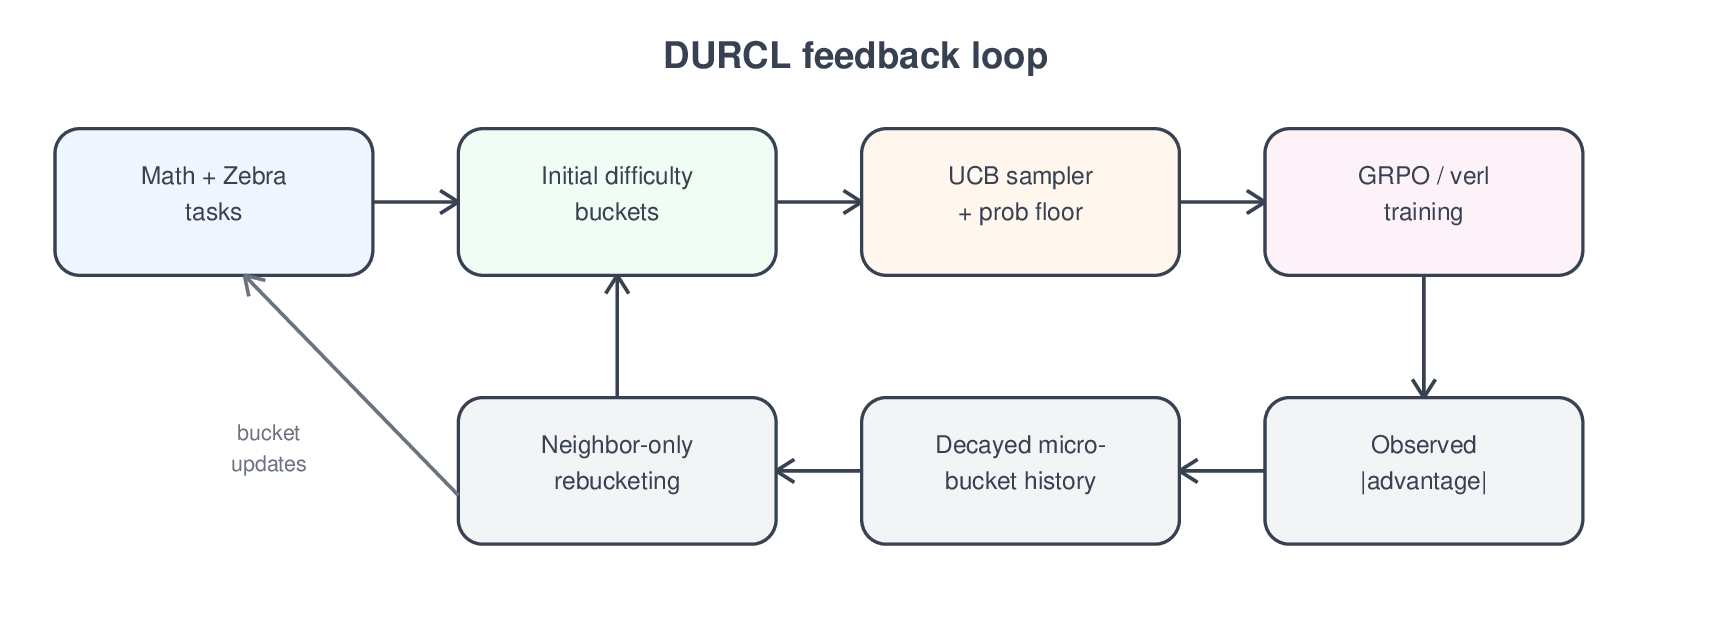

### fig_step200_math_zebra

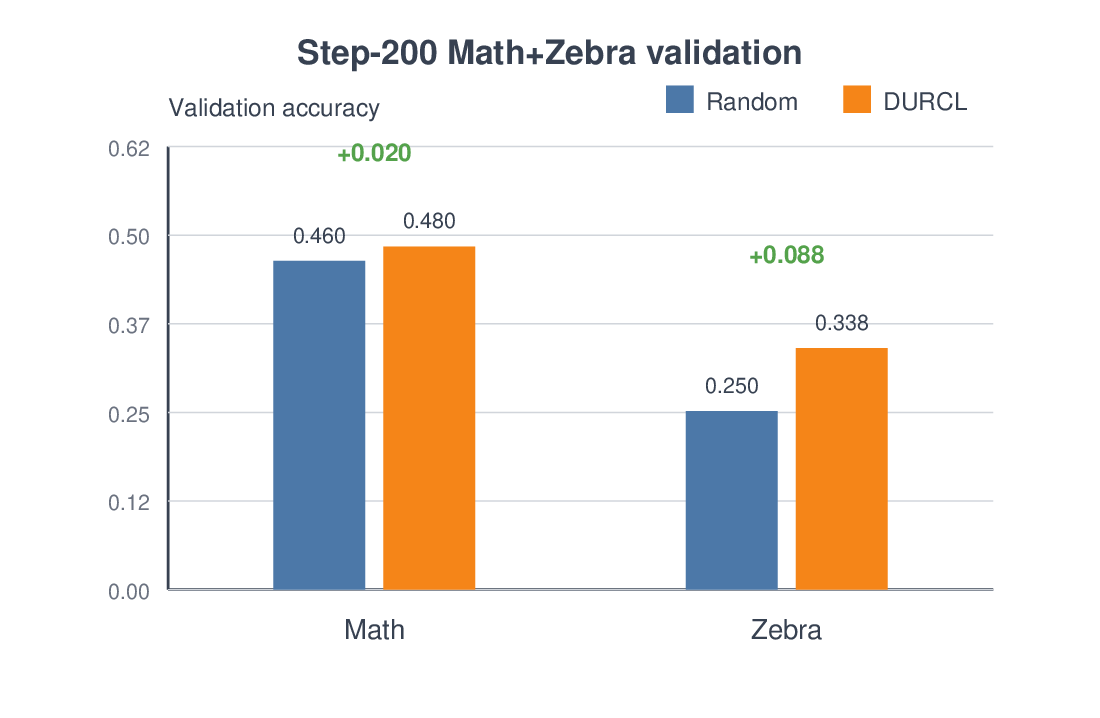

### fig_ucb_score_drift

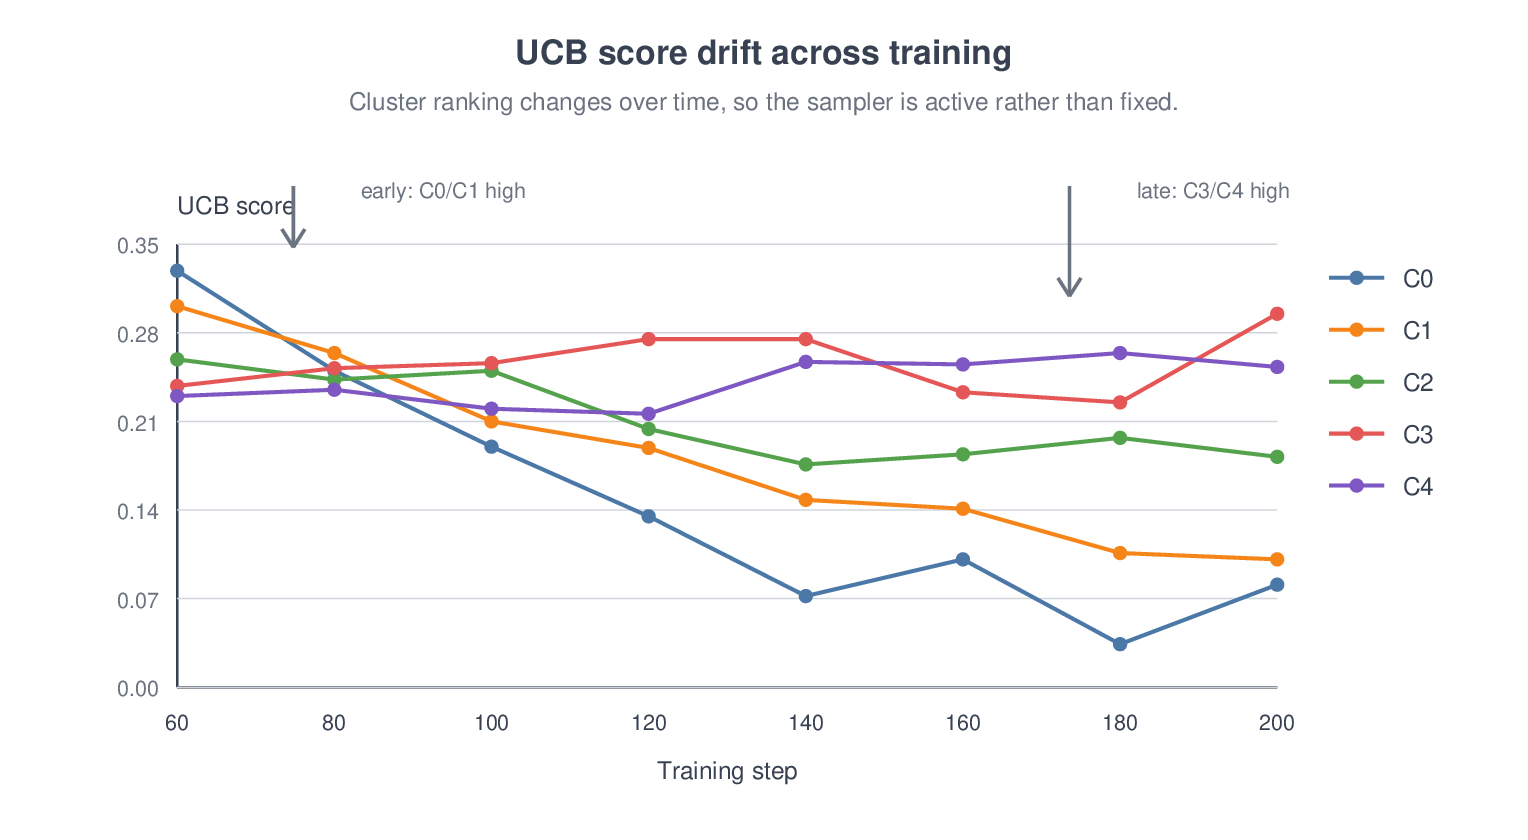

### fig_initial_accuracy_profile

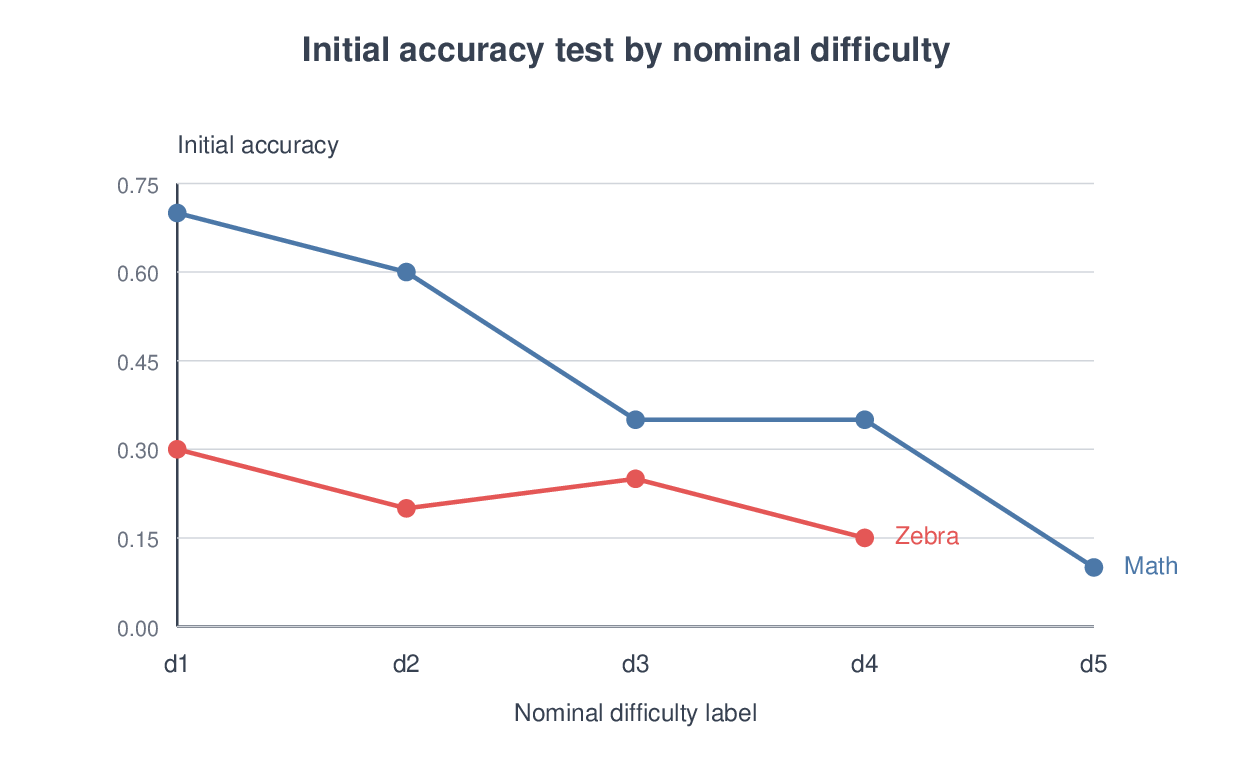

### fig_rebucket_composition

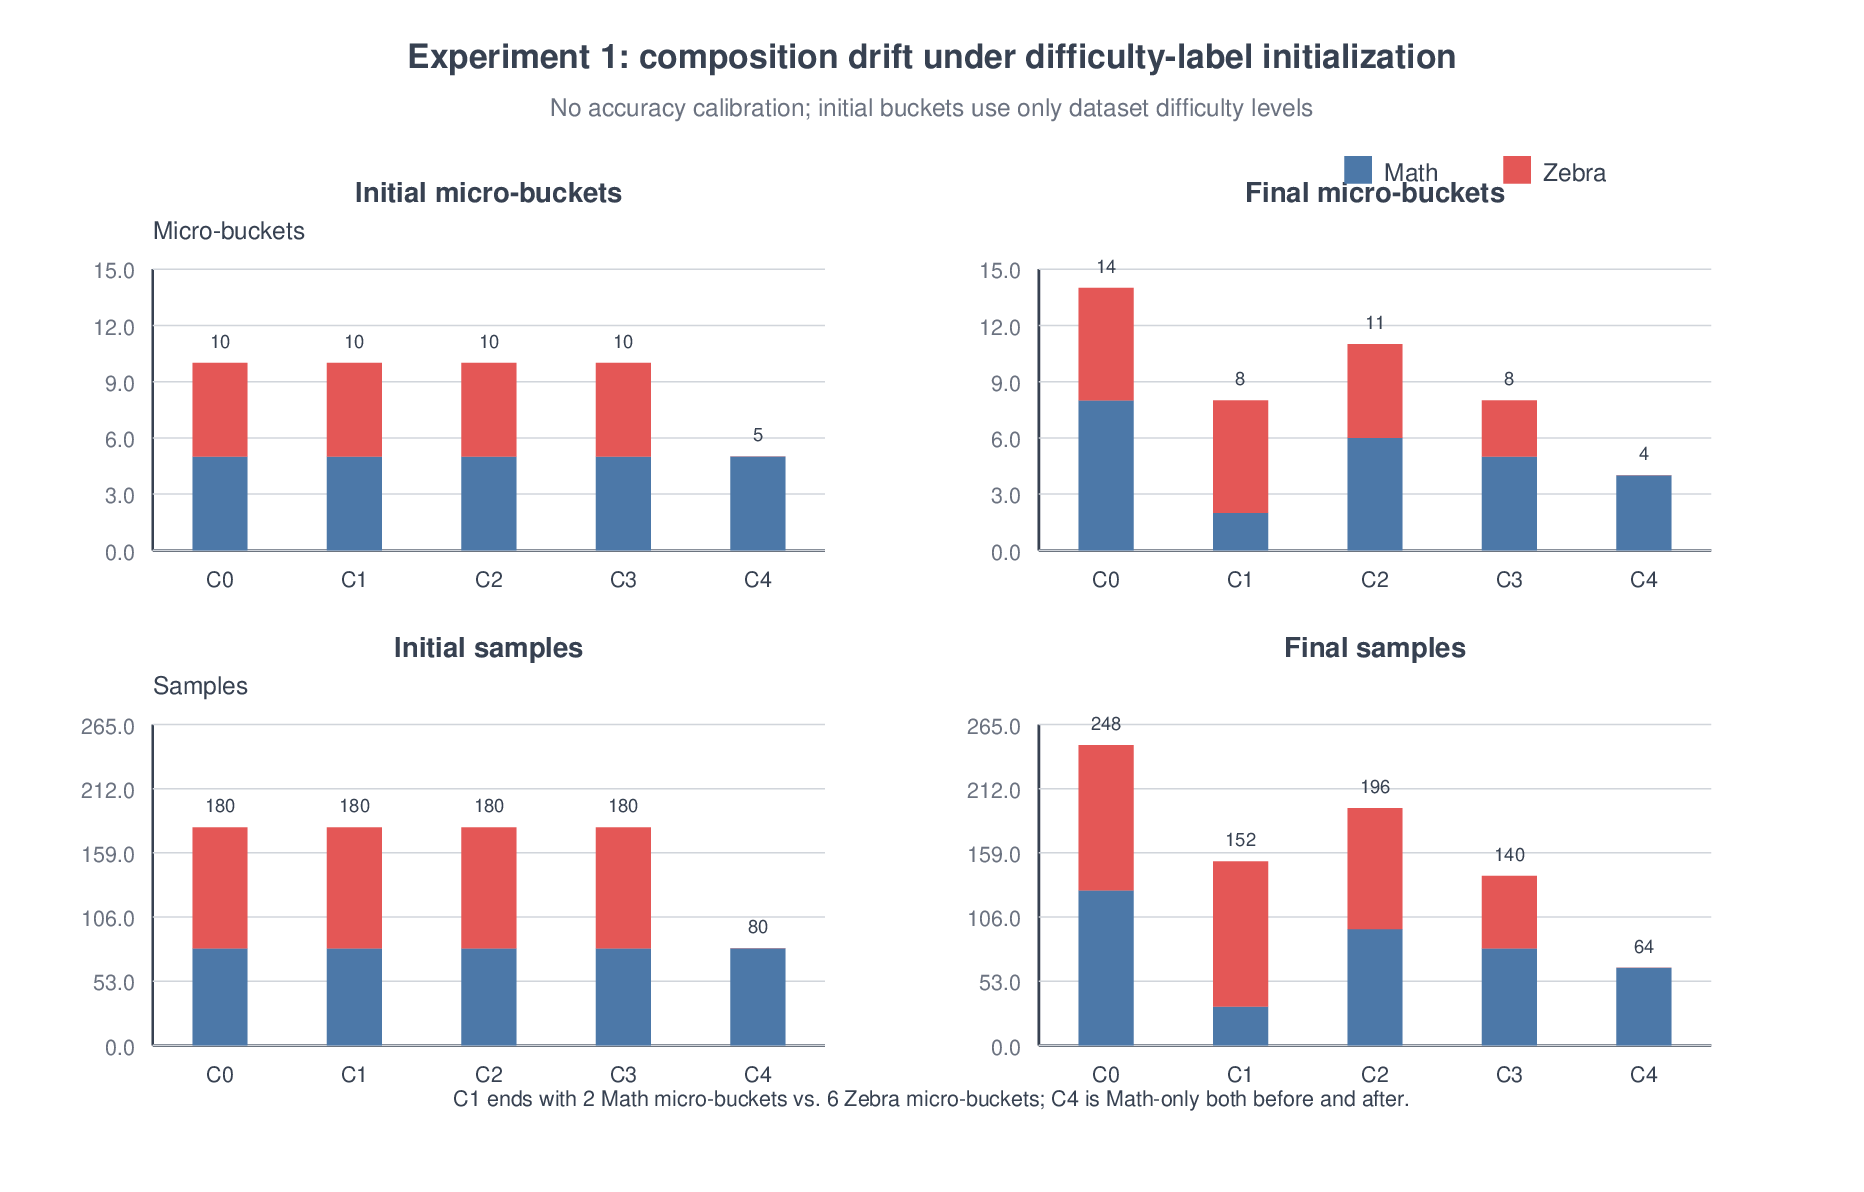

### fig_inferred_transition_matrix

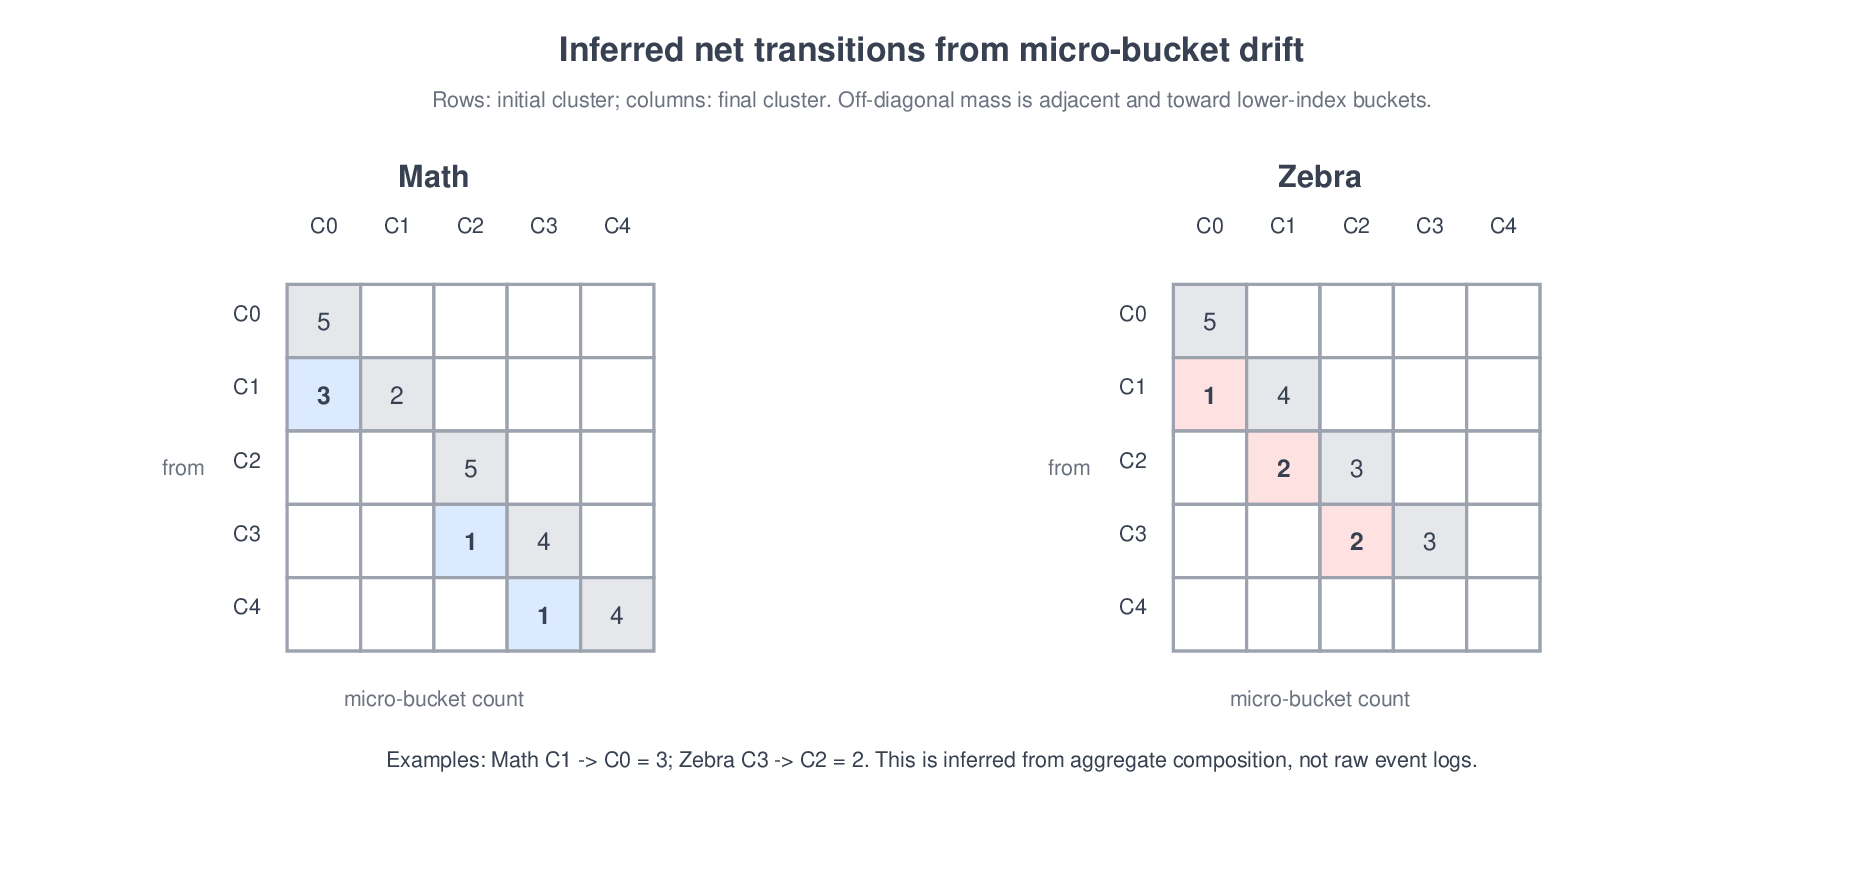

### fig_toy_rebucket_guardrails

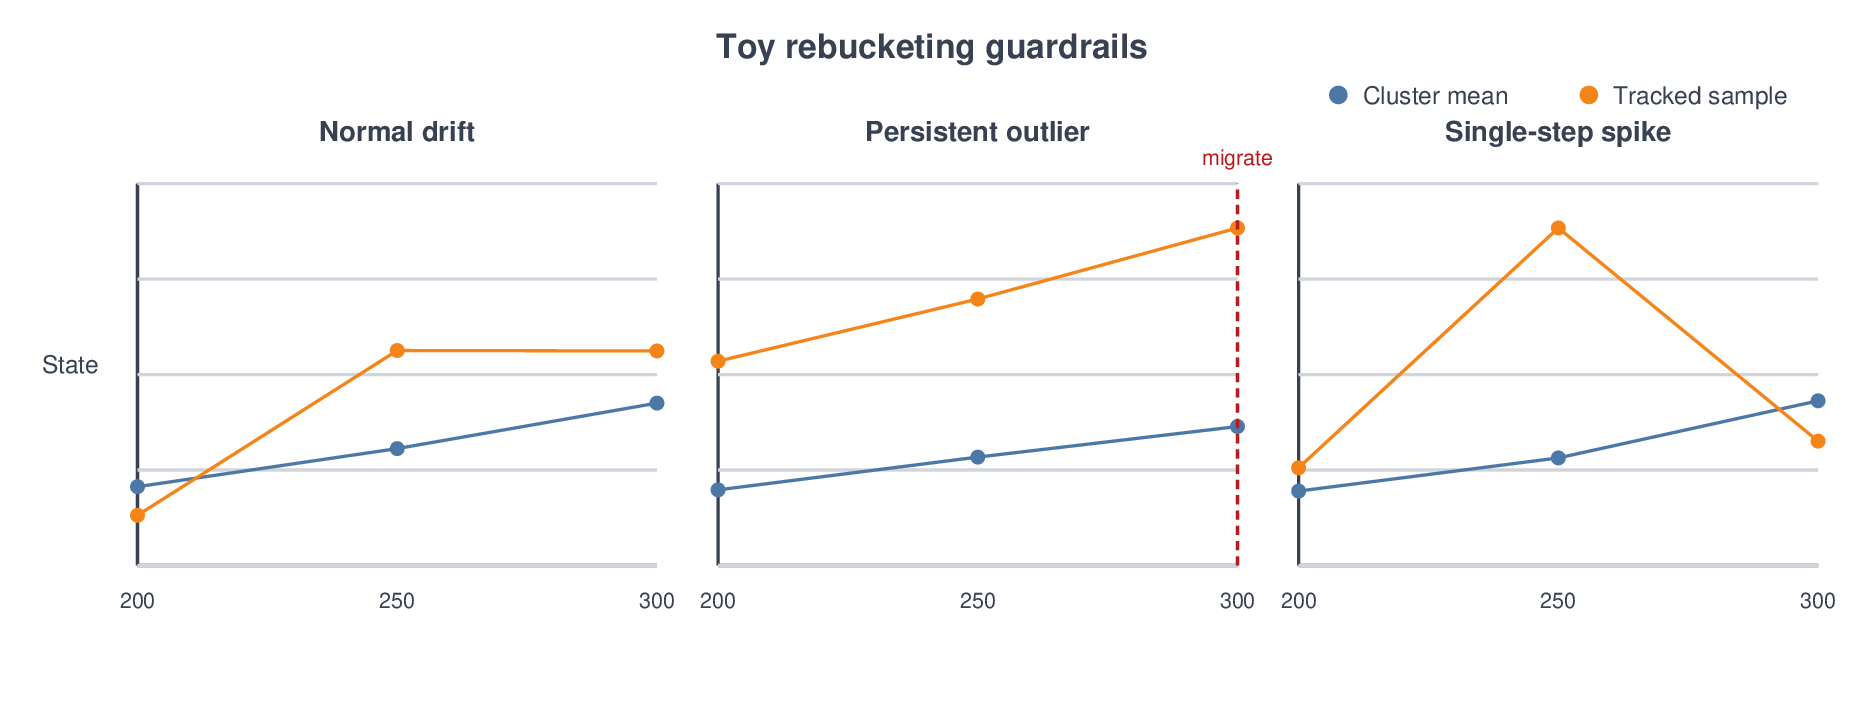

In [15]:
if REGENERATE_FIGURES:
    subprocess.run([sys.executable, str(ROOT / "paper" / "scripts" / "make_figures.py")], cwd=ROOT, check=True)
else:
    print("Using checked-in figures. Set REGENERATE_FIGURES=True to rebuild them.")

figure_names = [
    "fig_method_pipeline",
    "fig_step200_math_zebra",
    "fig_ucb_score_drift",
    "fig_initial_accuracy_profile",
    "fig_rebucket_composition",
    "fig_inferred_transition_matrix",
    "fig_toy_rebucket_guardrails",
]

for name in figure_names:
    png_path = ROOT / "paper" / "figures" / f"{name}.png"
    display(Markdown(f"### {name}"))
    display(Image(filename=str(png_path)))


Using checked-in toy-simulation artifacts. Set RERUN_TOY_SIMULATION=True to rerun them.


,name,steps,medium_mean,tracked,migration_steps
0,A_normal_drifting,"[200, 250, 300]","[0.4087218636389073, 0.451614712373887, 0.5028320014232464]","[0.3765015862931993, 0.5620471851887784, 0.5615470486280276]",[]
1,B_persistent_outlier,"[200, 250, 300]","[0.4051441266462077, 0.44203484670722987, 0.47645022188326186]","[0.55, 0.62, 0.7]",[300]
2,C_single_spike,"[200, 250, 300]","[0.4037889075255191, 0.441105433568532, 0.5054094268952166]","[0.43, 0.7, 0.46]",[]


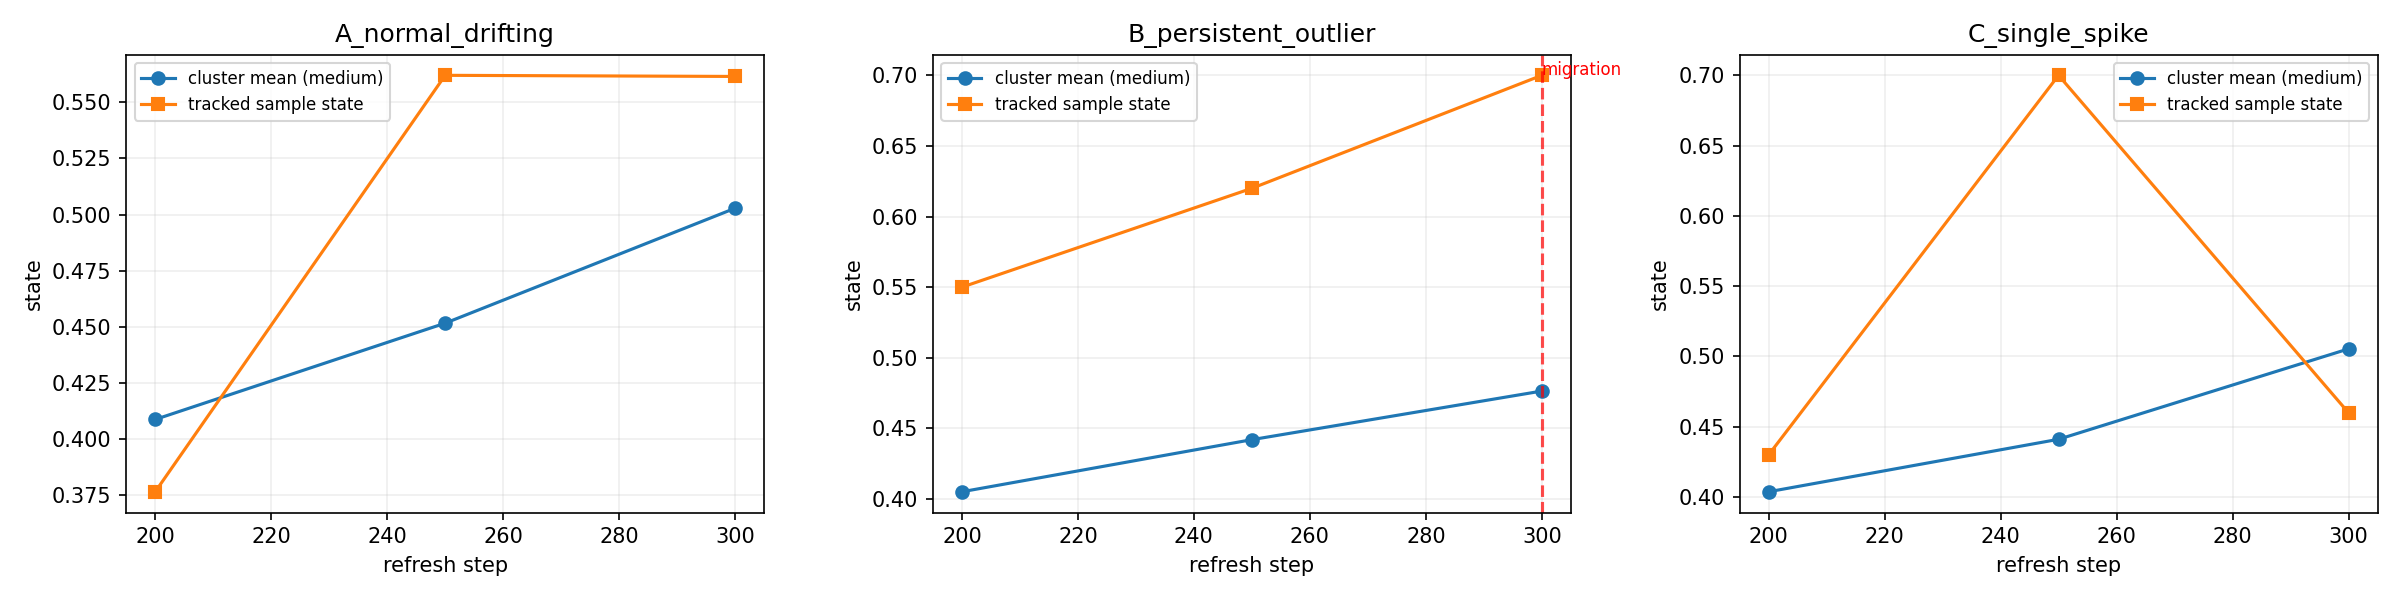

In [16]:
if RERUN_TOY_SIMULATION:
    subprocess.run([sys.executable, str(ROOT / "scripts" / "toy_simulation_rebucket.py")], cwd=ROOT, check=True)
else:
    print("Using checked-in toy-simulation artifacts. Set RERUN_TOY_SIMULATION=True to rerun them.")

toy_summary = json.loads((ROOT / "artifacts" / "toy_rebucket_summary.json").read_text(encoding="utf-8"))
display(pd.DataFrame(toy_summary["scenarios"]))
display(Image(filename=str(ROOT / "artifacts" / "toy_rebucket_simulation.png")))


## Final Takeaway

This notebook intentionally separates **heavy training**, **replayable evaluation**, and **checked-in analysis**.
That matches the reality of the project:

- the repository already contains the important result tables, diagnostic traces, and paper figures;
- the notebook can bootstrap the repo and inspect those assets from a single file;
- checkpoint-based evaluation is supported through links;
- and full RL retraining remains available as a documented code path for a compatible multi-GPU environment.

In short, the notebook is meant to be both a readable submission artifact and a faithful index to the complete project workflow.
